In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax

In [2]:
n_states, start_width, threshold, measurement_prob, delta, mu, sigma, I, J = 7, 3, 1, 1, 1, np.asarray([[2]]), np.asarray([[1]]), 1, 5
model_type, transition_type = "Markov", "TIMESTEP"

In [3]:
intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
phi_0 = ca._get_initial_state(n_states, start_width,model_type=model_type, prior_type="Uniform")
intensity_matrix, phi_0

(Array([[[[-1. , -0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 1. , -1. , -0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -1. , -0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -1. , -0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -1. , -0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -1. ,  1. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -1. ]]]], dtype=float64),
 Array([[[[0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714]]]], dtype=float64))

In [4]:
jax.jacrev(ca.get_intensity_matrix, allow_int=True)(n_states, mu, sigma, model_type).size

49

In [5]:
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
Mc

Array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float64)

In [6]:

t = np.asarray([[4.5]]) #t_s #
phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=t, RA_s = None, delta=delta, 
Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
transition_type=transition_type, likelihood_type="SINGLE")

intensity_matrix.size, phi_t.size, (phi_t.size * phi_t.itemsize) / 1000000 # to get MB

(49, 7, 5.6e-05)

In [7]:
phi_jac = jax.jacfwd(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(49, 343, 0.002744)

In [8]:
intensity_matrix.shape, phi_t.shape, phi_jac.shape

((1, 1, 7, 7), (1, 1, 7, 1), (1, 1, 7, 1, 1, 1, 7, 7))

In [9]:
import jax.scipy as sci

In [10]:
ns=np.ceil(t/delta)

def perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT"):
     
    #ns=np.floor(RT/delta) # uncomment to include all response time
    
    T_delta = sci.linalg.expm(intensity_matrix * delta)

    # uncomment to include all response time
    # T_delta_remaining = sci.linalg.expm(intensity_matrix * ((RT_remaining[...,None,None]) if not npx.isscalar(RT_remaining) else (RT_remaining)))
    T_t = ca._timestep_transition_matrix(ns, T_delta, Mn)  #uncomment if fails
    return T_t

In [11]:
fn = jax.jacrev(perform_state_transition)
jax.jit(fn, static_argnames=["transition_type", "likelihood_type"]).lower(intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, transition_type, "SINGLE"
     ).cost_analysis()

{'flops': 846705.0,
 'transcendentals': 2.0,
 'bytes accessed': 4130222.0,
 'optimal_seconds': -5.0,
 'utilization0{}': 588.4910888671875,
 'utilization1{}': 266.0,
 'bytes accessed0{}': 1525383.0,
 'bytes accessed1{}': 756109.0,
 'bytes accessedout{}': 1848044.0,
 'utilization5{}': 19.0,
 'utilization11{}': 3.0,
 'utilization2{}': 68.0,
 'utilization15{}': 2.0,
 'utilization7{}': 9.0,
 'utilization12{}': 2.0,
 'bytes accessed9{}': -4.0,
 'utilization16{}': 2.0,
 'utilization14{}': 2.0,
 'utilization9{}': 7.0,
 'utilization3{}': 29.0,
 'bytes accessed4{}': 4.0,
 'utilization8{}': 9.0,
 'bytes accessed3{}': 11.0,
 'bytes accessed5{}': -4.0,
 'bytes accessed6{}': -4.0,
 'bytes accessed7{}': -4.0,
 'utilization6{}': 16.0,
 'utilization4{}': 21.0,
 'bytes accessed8{}': -4.0,
 'bytes accessed2{}': 679.0,
 'utilization13{}': 2.0,
 'utilization10{}': 3.0}

In [12]:
phi_jac = jax.jacrev(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(49, 343, 0.002744)

In [13]:
jax.jacfwd(jax.jacrev(ca.perform_state_transition))\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE").size

16807

In [14]:
jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type).size

49

In [15]:
fn = jax.jacrev(ca.likelihood)
jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).cost_analysis()

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float64[1,1]
The error occurred while tracing the function likelihood at /home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/decision_models/confidence_accumulation.py:439 for jit. This concrete value was not available in Python because it depends on the values of the arguments delta and RT_s.
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [16]:
import itertools as iter
n_states_arr, start_width_arr, delta, measurement_prob,  = [11, 51, 101], [2, 7, 11], 0.5, 0.8
threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [20, 200, 2000], [50] #,1000,10000
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov", "Quantum"]
df_memory = []
for (n_states, start_width), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    
    mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
    Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
    phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    
    fn_g = jax.jacrev(perform_state_transition, holomorphic=True if model_type=="Quantum" else False)
    fn_g_jit = jax.jit(fn_g, static_argnames=["delta", "transition_type", "likelihood_type"])
    
    #phi_jac = fn_jit \
    #(intensity_matrix, t, None, 
    # Mc, Mw, Mn, 
    # phi_0, delta, 
    # transition_type, "SINGLE")

    cost_st_tr_g = fn_g_jit.lower(intensity_matrix, t, None, 
            Mc, Mw, Mn, 
            phi_0, delta, transition_type, "SINGLE"
            ).cost_analysis()
    

    
    fn = perform_state_transition
    fn_jit = jax.jit(fn, static_argnames=["delta", "transition_type", "likelihood_type"])
    
    #phi_jac = fn_jit \
    #(intensity_matrix, t, None, 
    # Mc, Mw, Mn, 
    # phi_0, delta, 
    # transition_type, "SINGLE")

    cost_st_tr = fn_jit.lower(intensity_matrix, t, None, 
            Mc, Mw, Mn, 
            phi_0, delta, transition_type, "SINGLE"
            ).cost_analysis()
                    
    df_t = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        "States":n_states,
        "bytes_accessed_g": [cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        "flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory.append(df_t)
df_memory = pd.concat(df_memory)
df_memory

11 2 20 50 TIMESTEP Markov
0.007442671 22.833127424
11 2 20 50 TIMESTEP Quantum
0.015047927 46.707982336
11 2 200 50 TIMESTEP Markov
0.073067792 2276.54893568
11 2 200 50 TIMESTEP Quantum
0.147949824 4657.335238656
11 2 2000 50 TIMESTEP Markov
0.729318272 227586.978349056
11 2 2000 50 TIMESTEP Quantum
1.47696832 465598.244978688
51 7 20 50 TIMESTEP Markov
0.158865184 10546.358255616
51 7 20 50 TIMESTEP Quantum
0.322293888 21574.379896832
51 7 200 50 TIMESTEP Markov
1.56004736 1051887.688220672
51 7 200 50 TIMESTEP Quantum
3.169235712 2151943.434665984
51 7 2000 50 TIMESTEP Markov
15.571881984 105161346.52962406
51 7 2000 50 TIMESTEP Quantum
31.638687744 215139464.52197376
101 11 20 50 TIMESTEP Markov
0.622724096 162218.599514112
101 11 20 50 TIMESTEP Quantum
1.263675392 331846.28604928
101 11 200 50 TIMESTEP Markov
6.115251712 16179817.187639296
101 11 200 50 TIMESTEP Quantum
12.426350592 33100537.70867507
101 11 2000 50 TIMESTEP Markov
61.040582656 1617562199.2433581
101 11 2000 50 TI

,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed,flops
0,Markov,Internal,20,50,11,2.283313e+01,6.739853e+00,0.007443,0.001501
0,Quantum,Internal,20,50,11,4.670798e+01,6.769147e+00,0.015048,0.001513
0,Markov,Internal,200,50,11,2.276549e+03,6.709002e+02,0.073068,0.014916
0,Quantum,Internal,200,50,11,4.657335e+03,6.738285e+02,0.147950,0.015037
0,Markov,Internal,2000,50,11,2.275870e+05,6.705919e+04,0.729318,0.149066
0,Quantum,Internal,2000,50,11,4.655982e+05,6.735200e+04,1.476968,0.150279
0,Markov,Internal,20,50,51,1.054636e+04,1.334272e+04,0.158865,0.132724
0,Quantum,Internal,20,50,51,2.157438e+04,1.335625e+04,0.322294,0.132987
0,Markov,Internal,200,50,51,1.051888e+06,1.328025e+06,1.560047,1.319609
0,Quantum,Internal,200,50,51,2.151943e+06,1.329378e+06,3.169236,1.322213


phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    phi_jac = jax.jacfwd(ca.perform_state_transition, holomorphic=True if model_type=="Quantum" else False)(intensity_matrix, random_ts, None, delta, 
    Mc, Mn, Mw, phi_0, transition_type, "SINGLE")

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Memory(GB)") \
            .assign(**{"Memory(GB)": lambda df: df["Memory(GB)"].map({"bytes_accessed_g":"Jacobian of Transition Fn", "bytes_accessed":"Transition Function"})})
            ,
style="States",
y="value",
col="Model",
x="I",
hue="Memory(GB)",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log", xscale="log")
f.set_ylabels("Memory (GB)")
f.set_xlabels("Number of Participants")
f.set_titles(col_template="{col_name}")

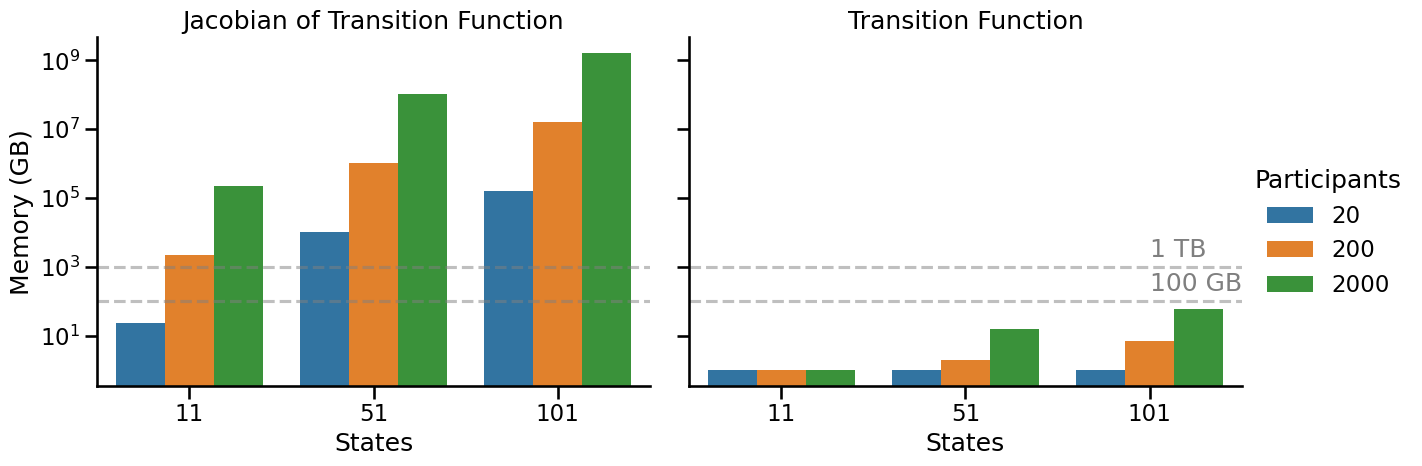

In [29]:
with sns.plotting_context("talk"):
    f = sns.catplot(
                df_memory.query("Model=='Markov'").melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_g":"Jacobian of Transition Function", "bytes_accessed":"Transition Function"})})
                .assign(I = lambda df: df.I.astype(str), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3,
    kind="bar", #facet_kws={"sharey":True}
    )
    f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    f.refline(y=1000, alpha=0.5)
    f.refline(y=100, alpha=0.5)
    f.legend.set_title("Participants")
    f.axes[0,1].text(y=200, x=2, s="100 GB", alpha=0.5)
    f.axes[0,1].text(y=2000, x=2, s="1 TB", alpha=0.5)

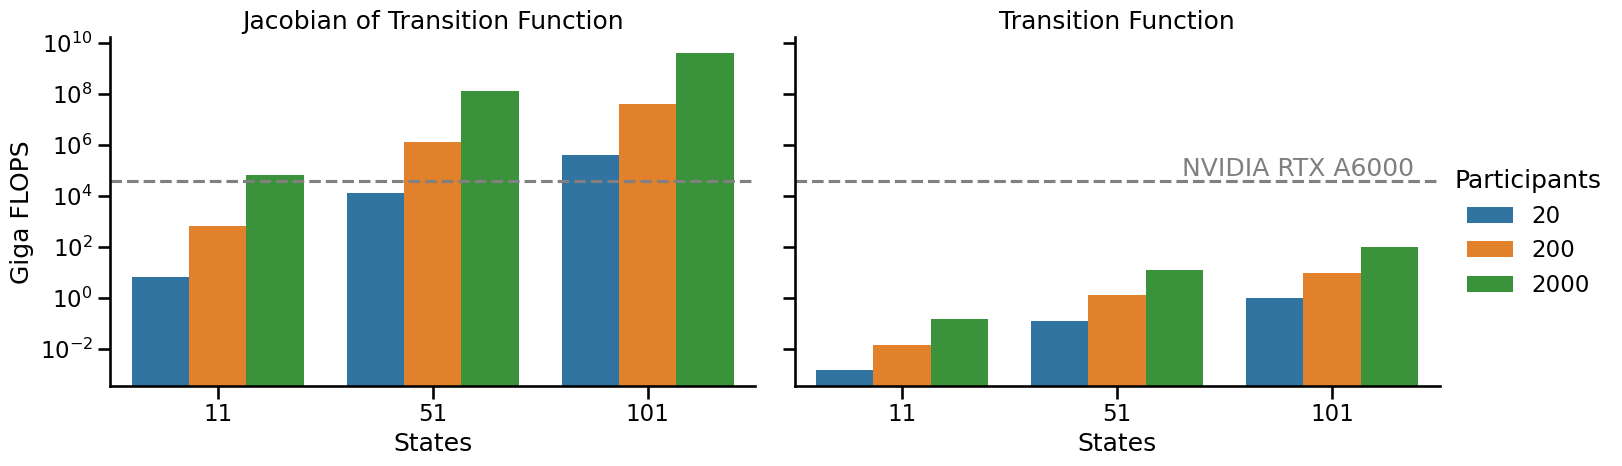

In [30]:
with sns.plotting_context("talk"):
    f = sns.catplot(
                df_memory.query("Model=='Markov'").melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
                .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Function", "flops":"Transition Function"})) 
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    hue="I",
    col="FLOPS",
    kind="bar", aspect=1.5
    )
    f.set(yscale="log")
    f.set_ylabels("Giga FLOPS")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    f.refline(y=38000)
    f.legend.set_title("Participants")
    f.axes[0,1].text(y=60000, x=1.3, s="NVIDIA RTX A6000", alpha=0.5)

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
            .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Fn", "flops":"Transition Function"})) 
            ,
style="States",
y="value",
col="Model",
x="I",
hue="FLOPS",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log")